# Section 3 — Mean-variance context

*Given these risk estimates, what would a mean-variance investor hold, and how much of the answer comes from the expected-return assumption?*

The five baskets are combined with three diversifiers (VXUS for non-US equity, TLT for long Treasuries, GLD for gold). The frontier is computed in closed form and checked against a numerical optimizer, under three expected-return scenarios. Expected returns here are scenarios and not forecasts; the point of the section is to show how the allocation responds to them.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from quiet_index import config as cfg
from quiet_index import data, pipeline, plots

pd.set_option("display.width", 200)
study_data = data.load_study_data() #cached prices, returns and index weights, cut off at the study end date

from quiet_index import frontier

section_1 = pipeline.run_section_1(study_data)
section_3 = pipeline.run_section_3(study_data, section_1)
tables = section_3["tables"]

## 3.1 Inputs

Eight assets on their common history. The optimizer is given simple returns, since a portfolio's return is linear in the simple returns of its holdings, and both $\mu$ and $\Sigma$ are annualized.

Three scenarios for $\mu$:

- Sample means: the historical average return of each asset, taken at face value.
- 50% shrinkage: each sample mean moved halfway toward the average of all eight.
- No views: every asset is assumed to earn the same, so only the covariance matrix matters.

In [2]:
print(f"3-month T-bill rate on {study_data['tbill_yield'].index[-1].date()}: {section_3['risk_free_rate']:.2%}")
(tables["s3_inputs"] * 100).round(1) #expected return under each scenario and annualized volatility, in percent

3-month T-bill rate on 2026-09-30: 4.03%


,Sample means,50% shrinkage,No views,annualized_volatility
asset,,,,
M7,37.9,28.7,19.5,30.3
AI_HI_MOM_HI,30.5,25.0,19.5,28.7
AI_HI_MOM_LO,24.1,21.8,19.5,26.1
AI_LO_MOM_HI,20.3,19.9,19.5,18.0
AI_LO_MOM_LO,17.0,18.2,19.5,17.8
VXUS,11.2,15.4,19.5,18.4
TLT,-2.2,8.6,19.5,16.1
GLD,16.8,18.1,19.5,18.0


In [3]:
tables["s3_correlations"].round(2)

,M7,AI_HI_MOM_HI,AI_HI_MOM_LO,AI_LO_MOM_HI,AI_LO_MOM_LO,VXUS,TLT,GLD
asset,,,,,,,,
M7,1.00,0.80,0.76,0.51,0.47,0.69,-0.06,0.11
AI_HI_MOM_HI,0.80,1.00,0.79,0.59,0.53,0.79,-0.10,0.15
AI_HI_MOM_LO,0.76,0.79,1.00,0.62,0.68,0.78,-0.12,0.12
AI_LO_MOM_HI,0.51,0.59,0.62,1.00,0.75,0.66,-0.17,0.09
AI_LO_MOM_LO,0.47,0.53,0.68,0.75,1.00,0.66,-0.18,0.04
VXUS,0.69,0.79,0.78,0.66,0.66,1.00,-0.07,0.29
TLT,-0.06,-0.10,-0.12,-0.17,-0.18,-0.07,1.00,0.23
GLD,0.11,0.15,0.12,0.09,0.04,0.29,0.23,1.00


The sample means are the realized returns of a universe of survivors over a period that was very good for large US technology companies and poor for long-dated bonds: 38% a year for the Mag-7 and −2% for TLT. Nobody should treat those as expectations, which is the reason for the other two scenarios.

The correlation table shows where diversification is available. VXUS has a correlation of between 0.66 and 0.79 with the five baskets, so it diversifies very little. TLT is slightly negatively correlated with all five (−0.06 to −0.18) and gold is close to uncorrelated with them (0.04 to 0.15).

## 3.2 Closed-form frontier, checked against an optimizer

With $A = \mathbf{1}^\top\Sigma^{-1}\mathbf{1}$, $B = \mu^\top\Sigma^{-1}\mathbf{1}$, $C = \mu^\top\Sigma^{-1}\mu$ and $D = AC - B^2$, the minimum-variance weights for a target return $m$ are

$$w^* = \Sigma^{-1}\left(\lambda\,\mu + \gamma\,\mathbf{1}\right), \qquad \lambda = \frac{A m - B}{D}, \qquad \gamma = \frac{C - B m}{D}$$

and the tangency portfolio for a risk-free rate $r$ is $\Sigma^{-1}(\mu - r\mathbf{1}) / (B - A r)$. Both allow short positions. The same problem is then handed to a numerical optimizer (SLSQP) with the budget and target-return constraints, and the two sets of weights are compared.

In [4]:
tables["s3_closed_form_check"] #largest difference in any single weight between the formula and the optimizer

,closed_form_volatility,optimizer_volatility,max_weight_gap
target_return,,,
0.05,0.100457,0.100457,1.743008e-07
0.10,0.097862,0.097862,2.273108e-07
0.15,0.103444,0.103444,2.142762e-08
0.20,0.116028,0.116028,3.395778e-08
0.30,0.154599,0.154599,3.093628e-08


The formula and the optimizer agree to within 0.0000003 in every weight at each of the five target returns, which confirms both the implementation of the closed form and the optimizer settings that the long-only portfolios below depend on. The formula is also checked in `tests/` against a four-asset case with a known solution.

## 3.3 Portfolios

For each scenario: the tangency portfolio (shorts allowed, closed form), the long-only tangency portfolio, and the long-only portfolios with the highest expected return at 12% and 18% volatility. Under "No views" the only portfolios that are defined are the minimum-variance ones.

In [5]:
(tables["s3_portfolio_weights"] * 100).round(1) #weights in percent

M7  AI_HI_MOM_HI  AI_HI_MOM_LO  AI_LO_MOM_HI  AI_LO_MOM_LO   VXUS   TLT    GLD
scenario      portfolio                                                                                                    
Sample means  Tangency                     87.8          54.9         -14.8          70.4          70.7 -237.6 -48.7  117.2
              Tangency, long-only          33.5           0.0           0.0          27.9           0.0    0.0   0.0   38.6
              Long-only, 12% vol           14.5           0.0           0.0          23.5          14.7    0.0  13.3   34.0
              Long-only, 18% vol           47.0           0.0           0.0          19.1           0.0    0.0   0.0   34.0
50% shrinkage Tangency                     23.4          11.3          -9.2          30.2          37.1  -53.2  17.8   42.6
              Tangency, long-only          12.2           0.0           0.0          22.6          16.1    0.0  17.3   31.8
              Long-only, 12% vol           14.5           0.0           0.0          23.5          14.7    0.0  13.3   34.0
              Long-only, 18% vol           47.0           0.0           0.0          19.1           0.0    0.0   0.0   34.0
No views      Minimum variance              2.3          -2.9          -7.4          17.1          26.1    7.1  39.5   18.2
              Minimum variance, long-only   0.0           0.0           0.0          16.5          23.9    0.0  40.4   19.1

In [6]:
tables["s3_portfolio_statistics"].round(3)

expected_return  volatility  sharpe_ratio
scenario      portfolio                                                             
Sample means  Tangency                               0.669       0.345         1.822
              Tangency, long-only                    0.249       0.158         1.317
              Long-only, 12% vol                     0.182       0.120         1.179
              Long-only, 18% vol                     0.274       0.180         1.299
50% shrinkage Tangency                               0.214       0.127         1.364
              Tangency, long-only                    0.182       0.115         1.235
              Long-only, 12% vol                     0.188       0.120         1.232
              Long-only, 18% vol                     0.234       0.180         1.078
No views      Minimum variance                         NaN       0.098           NaN
              Minimum variance, long-only              NaN       0.098           NaN

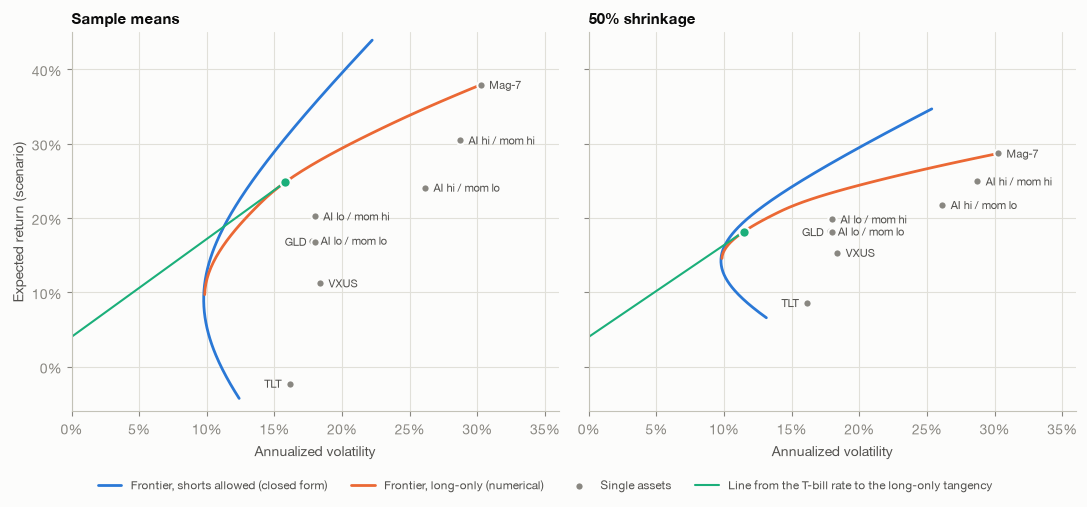

In [7]:
plots.plot_frontier(section_3["sample_means"], section_3["var_covar_matrix"], section_3["risk_free_rate"]);

The unconstrained tangency portfolio is not an allocation anyone would hold. Under sample means it is long 88% in the Mag-7, 55% in the AI-high, momentum-high basket, about 70% in each AI-low basket and 117% in gold, funded by short positions of 238% in VXUS, 49% in TLT and 15% in the AI-high, momentum-low basket. The formula is doing what it was asked to do. VXUS has a high correlation with the baskets and a much lower sample mean, so it looks like an inexpensive hedge, and the optimizer shorts it at more than twice the portfolio's capital to finance everything else. A position of that size is a statement about estimation error in the inputs. With 50% shrinkage the same portfolio falls to a short of 53% in VXUS and long positions of between 11% and 43%, and its Sharpe ratio falls from 1.82 to 1.36.

Once short positions are ruled out, it is the expected-return assumption that decides how much Mag-7 is held. The long-only tangency portfolio holds 33.5% in the Mag-7 under sample means, 12.2% under shrinkage, and the minimum-variance portfolio under no views holds none. Over the same three scenarios the number of assets held rises from three to five and then falls to four, and TLT goes from zero to 17% to 40%.

The two AI-high baskets receive no weight in any long-only portfolio. Once the Mag-7 is available, the AI-high baskets offer a lower return at a correlation of about 0.8 with it, and once gold and the AI-low baskets are available there are better diversifiers. The index, for comparison, holds 32% in those two baskets.

The volatility-target portfolios are identical under sample means and under shrinkage, and this is a property of the method. Shrinking every expected return halfway toward a common value $\bar\mu$ gives $\mu_s = \tfrac{1}{2}\mu + \tfrac{1}{2}\bar\mu\mathbf{1}$. Because the weights sum to one, the portfolio return becomes $\mu_s^\top w = \tfrac{1}{2}\mu^\top w + \tfrac{1}{2}\bar\mu$, which ranks every portfolio in exactly the same order as before. The portfolio with the highest expected return at a given volatility is therefore the same portfolio. Shrinkage toward a common mean changes the level of expected returns and it changes the tangency portfolio, because the T-bill rate is not shrunk along with the asset means, but it leaves the composition of the efficient frontier untouched. It is worth knowing this before reaching for shrinkage as a remedy for concentrated allocations.

## Conclusions

The covariance matrix from Section 2 says where the risk is. This section shows that, taken by itself, it says very little about what to hold. With no return views, a long-only investor would hold 40% in long Treasuries, 40% in the two AI-low baskets and 19% in gold, with nothing in the Mag-7 or the AI-high baskets, for a volatility of 9.8%. Any allocation to the Mag-7 in these portfolios is there because of an assumed return, and its size moves from 0% to 12% to 34% as that assumption moves from no views to shrunk means to sample means.

The weights are therefore far more sensitive to the expected-return scenario than to any of the estimator choices examined in Section 2. That is a familiar result in mean-variance work, and it is the reason the expected returns in this study are labelled scenarios throughout.